In [2]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "master2025"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

# ---------------------------------------
# Cypher Queries: universell für jede DB
# ---------------------------------------
COUNT_NODES = """MATCH (n) RETURN count(n) AS nodes;"""
COUNT_EDGES = """MATCH ()-[r]->() RETURN count(r) AS edges;"""

def get_counts(db_name: str) -> dict:
    """Liefert die Anzahl aller Knoten und Kanten für eine Datenbank."""
    with driver.session(database=db_name) as session:
        nodes = session.run(COUNT_NODES).single()["nodes"]
        edges = session.run(COUNT_EDGES).single()["edges"]
    return {"database": db_name, "nodes": nodes, "edges": edges}


# ---------------------------------------
# Deine 4 Datenbanken
# ---------------------------------------
DBS = ["simplekg", "llmakg", "llmagraphtrkg"]

results = [get_counts(db) for db in DBS]

driver.close()

df = pd.DataFrame(results)

# Schönere Namen für die Thesis
rename_map = {
    "simplekg": "KG_SimleKG",
    "neo4j": "KG_Neo4j_Extractor_Version2",
    "llmakg": "KG_LlamaIndex",
    "llmagraphtrkg": "KG_Langchain",
}
df["database"] = df["database"].replace(rename_map)

print(df)


        database  nodes  edges
0     KG_SimleKG   7175  12197
1  KG_LlamaIndex   8941  24472
2   KG_Langchain   5207  17074


In [3]:
# DataFrame long-format
df_long = df.melt(
    id_vars="database",
    value_vars=["nodes", "edges"],
    var_name="type",
    value_name="count",
)
import seaborn as sns

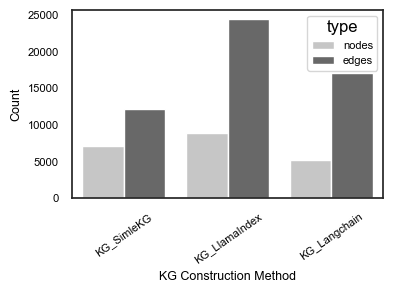

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


# Schritt 1: Seaborn Theme setzen
sns.set_theme(style="white")

# Schritt 2: Schrift wirklich schwarz machen
plt.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "legend.labelcolor": "black",
})

# ---- Schrift global anpassen ----
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

# ---- Farben definieren ----
# Beispiel: dezente professionelle Farben
#palette = ["#4C72B0", "#55A868"]  # Blau & Grün

plt.figure(figsize=(4, 3))

sns.barplot(
    data=df_long,
    x="database",
    y="count",
    hue="type",
    palette="Greys"   # oder "gray"
)
plt.xlabel("KG Construction Method")
plt.ylabel("Count")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()


In [52]:
from neo4j import GraphDatabase
import pandas as pd

URI = "neo4j://127.0.0.1:7687"
AUTH_USER = "neo4j"
AUTH_PASSWORD = "testmaster123"

driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

# ---------------------------------------
# Cypher Queries: universell für jede DB
# ---------------------------------------
COUNT_NODES = """MATCH (n) RETURN count(n) AS nodes;"""
COUNT_EDGES = """MATCH ()-[r]->() RETURN count(r) AS edges;"""

def get_counts(db_name: str) -> dict:
    """Liefert die Anzahl aller Knoten und Kanten für eine Datenbank."""
    with driver.session(database=db_name) as session:
        nodes = session.run(COUNT_NODES).single()["nodes"]
        edges = session.run(COUNT_EDGES).single()["edges"]
    return {"database": db_name, "nodes": nodes, "edges": edges}


# ---------------------------------------
# Deine 4 Datenbanken
# ---------------------------------------
DBS = ["eval-llmgraph", "eval-llmaindex" ,"eval-simlekg",]

results = [get_counts(db) for db in DBS]

driver.close()

df = pd.DataFrame(results)

# Schönere Namen für die Thesis
rename_map = {
    "eval-simlekg": "KG_Neo4j_Extractor_Version1",
    "eval-llmaindex": "KG_LlamaIndex_Extractor",
    "eval-llmgraph": "KG_Langchain_Extractor",
}
df["database"] = df["database"].replace(rename_map)

print(df)


                      database  nodes  edges
0       KG_Langchain_Extractor     71    117
1      KG_LlamaIndex_Extractor    129    276
2  KG_Neo4j_Extractor_Version1     82    112


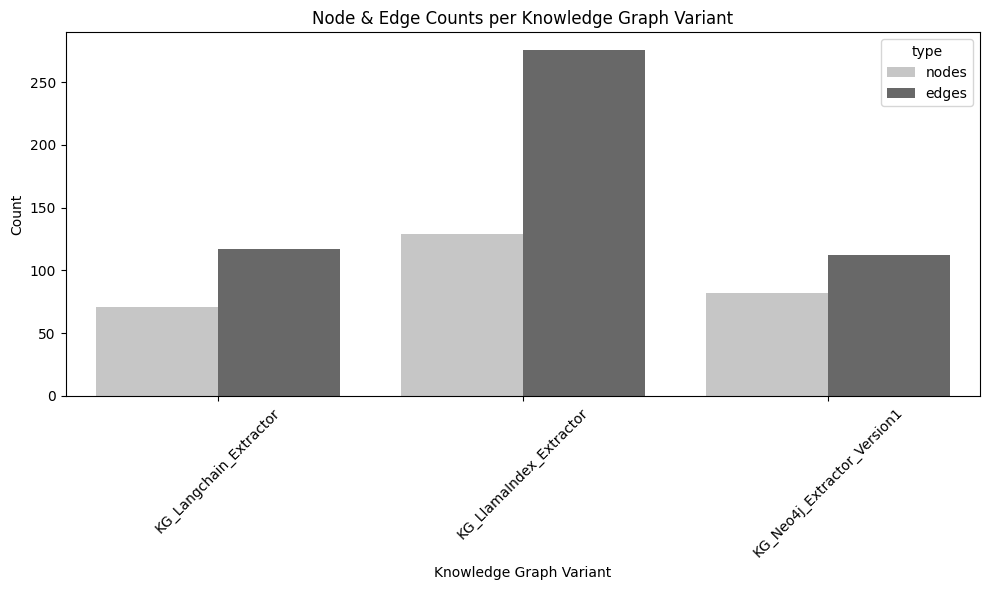

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
df_long = df.melt(
    id_vars="database",
    value_vars=["nodes", "edges"],
    var_name="type",
    value_name="count",
)
# --- Schriftfarbe überall auf Schwarz setzen ---
plt.rcParams['text.color'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'
plt.rcParams['legend.labelcolor'] = 'black'

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_long,
    x="database",
    y="count",
    hue="type",
    palette="Greys"    # Grautöne für die Bars
)

plt.title("Node & Edge Counts per Knowledge Graph Variant")
plt.xlabel("Knowledge Graph Variant")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [54]:
driver = GraphDatabase.driver(URI, auth=(AUTH_USER, AUTH_PASSWORD))

def run_query_to_df(query: str, database: str) -> pd.DataFrame:
    """Generic function to run a Cypher query on a given database and return a DataFrame."""
    with driver.session(database=database) as session:
        result = session.run(query)
        records = list(result)
        
        if not records:
            return pd.DataFrame()  # empty
        
        # Neo4j returns dict-like records → convert to list of dicts
        rows = [r.data() for r in records]
        return pd.DataFrame(rows)

In [55]:
DATABASE_llmgraph="eval-llmgraph"
DATABASE_llmaindex="eval-llmaindex"
DATABASE_simple_kg = "eval-simlekg"

In [74]:
query_llmagraph = """MATCH (s)-[r]-(o)


OPTIONAL MATCH (s)-[:MENTIONS]-(cs1:Chunk)
OPTIONAL MATCH (cs2:Chunk)-[:MENTIONS]-(s)


OPTIONAL MATCH (o)-[:MENTIONS]-(co1:Chunk)
OPTIONAL MATCH (co2:Chunk)-[:MENTIONS]-(o)


WHERE NOT type(r) CONTAINS "MENTIONS"
  AND NOT toLower(type(r)) CONTAINS "document"

RETURN
  coalesce(s.id, s.name, s.entityType, "UNKNOWN") AS subject,
  type(r)                                         AS relation,
  coalesce(o.id, o.name, o.entityType, "UNKNOWN") AS object,

  coalesce(cs1.id, cs2.id, "NO_CHUNK") AS subject_chunk,
  coalesce(co1.id, co2.id, "NO_CHUNK") AS object_chunk

;
"""
query_simplekg ="""MATCH (s)-[r]-(o)
OPTIONAL MATCH (s)-[:FROM_CHUNK]-(cs1:Chunk)
OPTIONAL MATCH (cs2:Chunk)-[:FROM_CHUNK]-(s)
OPTIONAL MATCH (cs1:Chunk)-[:FROM_DOCUMENT]-(d)
OPTIONAL MATCH (cs2:Chunk)-[:FROM_DOCUMENT]-(d1)

// Chunk-ID für Objekt
OPTIONAL MATCH (o)-[:FROM_CHUNK]-(co1:Chunk)
OPTIONAL MATCH (co2:Chunk)-[:FROM_CHUNK]-(o)
OPTIONAL MATCH (co1:Chunk)-[:FROM_DOCUMENT]-(do)
OPTIONAL MATCH (co2:Chunk)-[:FROM_DOCUMENT]-(do1)

WHERE NOT type(r) CONTAINS ("CHUNK")
  AND NOT toLower(type(r)) CONTAINS "document"
RETURN
  coalesce(s.type, s.name, "UNKNOWN") AS subject,
  type(r)                             AS relation,
  coalesce(o.type, o.name, "UNKNOWN") AS object,
  coalesce(d.chunk_id, d1.chunk_id, "NO_CHUNK") AS subject_chunk,
  coalesce(do.chunk_id, do1.chunk_id, "NO_CHUNK") AS object_chunk;"""

query_llmaindex = """MATCH (s)-[r]-(o)


WHERE NOT type(r) CONTAINS "MENTIONS"
  AND NOT toLower(type(r)) CONTAINS "document"

RETURN
  coalesce(s.id, s.name, s.entityType, "UNKNOWN") AS subject,
  type(r)                                         AS relation,
  coalesce(o.id, o.name, o.entityType, "UNKNOWN") AS object,

  coalesce(s.chunk_id, "NO_CHUNK") AS subject_chunk,
  coalesce(o.chunk_id, "NO_CHUNK") AS object_chunk;
  """

In [76]:
df_llmagraph = run_query_to_df(query_llmagraph, DATABASE_llmgraph)
df_llmaindex = run_query_to_df(query_llmaindex, DATABASE_llmaindex)
df_simplekg = run_query_to_df(query_simplekg, DATABASE_simple_kg)

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownPropertyKeyWarning} {category: UNRECOGNIZED} {title: The provided property key is not in the database} {description: One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: entityType)} {position: line: 8, column: 28, offset: 140} for query: 'MATCH (s)-[r]-(o)\n\n\nWHERE NOT type(r) CONTAINS "MENTIONS"\n  AND NOT toLower(type(r)) CONTAINS "document"\n\nRETURN\n  coalesce(s.id, s.name, s.entityType, "UNKNOWN") AS subject,\n  type(r)                                         AS relation,\n  coalesce(o.id, o.name, o.entityType, "UNKNOWN") AS object,\n\n  coalesce(s.chunk_id, "NO_CHUNK") AS subject_chunk,\n  coalesce(o.chunk_id, "NO_CHUNK") AS object_chunk;\n  '
Received notification from DBMS server: {severity: WARNING} {code: 

In [77]:
df_llmagraph

,subject,relation,object,subject_chunk,object_chunk
0,Modulino Buzzer-datasheet::c4,FROM_DOCUMENT,Modulino Buzzer-datasheet.pdf,NO_CHUNK,NO_CHUNK
1,Modulino Buzzer-datasheet.pdf,FROM_DOCUMENT,Modulino Buzzer-datasheet::c4,NO_CHUNK,NO_CHUNK
2,Modulino Buzzer-datasheet::c4,MENTIONS,Modulino Buzzer,NO_CHUNK,Modulino Buzzer-datasheet::c4
3,Modulino Buzzer,MENTIONS,Modulino Buzzer-datasheet::c4,Modulino Buzzer-datasheet::c4,NO_CHUNK
4,Modulino Buzzer-datasheet::c4,MENTIONS,I2C Commands,NO_CHUNK,Modulino Buzzer-datasheet::c4
...,...,...,...,...,...
328,Sensors,CONNECTS_TO,I2C Communication,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10
329,Sensors,CONNECTS_TO,I2C Communication,Due-datasheet::c2,Arduino Portenta Mid Carrier Proto Shield::c10
330,Sensors,CONNECTS_TO,I2C Communication,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10
331,I2C Communication,CONNECTS_TO,Peripherals,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10


In [78]:
df_llmagraph_filt=df_llmagraph[df_llmagraph["subject_chunk"] != "NO_CHUNK"]
df_llmagraph_filt2=df_llmagraph_filt[df_llmagraph_filt["object_chunk"] != "NO_CHUNK"]

df_llmagraph_filt2

,subject,relation,object,subject_chunk,object_chunk
38,Arduino Due,USES,Atmel Sam3X8E,Due-datasheet::c2,Due-datasheet::c2
39,Atmel Sam3X8E,USES,Arduino Due,Due-datasheet::c2,Due-datasheet::c2
40,Arduino Due,SUPPORTS,Embedded Systems Development,Due-datasheet::c2,Due-datasheet::c2
41,Embedded Systems Development,SUPPORTS,Arduino Due,Due-datasheet::c2,Due-datasheet::c2
42,Arduino Due,SUPPORTS,Robotics,Due-datasheet::c2,Due-datasheet::c2
...,...,...,...,...,...
328,Sensors,CONNECTS_TO,I2C Communication,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10
329,Sensors,CONNECTS_TO,I2C Communication,Due-datasheet::c2,Arduino Portenta Mid Carrier Proto Shield::c10
330,Sensors,CONNECTS_TO,I2C Communication,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10
331,I2C Communication,CONNECTS_TO,Peripherals,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10


In [79]:
df_llmaindex

,subject,relation,object,subject_chunk,object_chunk
0,Arduino due,Has,32-bit architecture,Due-datasheet::c2,Due-datasheet::c2
1,32-bit architecture,Has,Arduino due,Due-datasheet::c2,Due-datasheet::c2
2,Arduino due,Has,Clock speed of 84 mhz,Due-datasheet::c2,Due-datasheet::c2
3,Clock speed of 84 mhz,Has,Arduino due,Due-datasheet::c2,Due-datasheet::c2
4,Arduino due,Combines,Atmel sam3x8e microcontroller,Due-datasheet::c2,Due-datasheet::c2
...,...,...,...,...,...
221,Environmental monitoring,Enables,Nicla sense me,Arduino Portenta Mid Carrier Proto Shield::c9,Arduino Portenta Mid Carrier Proto Shield::c9
222,Eslov connectors,For,I2c communication,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10
223,I2c communication,For,Eslov connectors,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10
224,Qwiic connector,For,I2c communication,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c10


In [80]:
df_simplekg

,subject,relation,object,subject_chunk,object_chunk
0,UNKNOWN,FROM_DOCUMENT,UNKNOWN,NO_CHUNK,NO_CHUNK
1,UNKNOWN,FROM_DOCUMENT,UNKNOWN,NO_CHUNK,NO_CHUNK
2,Arduino Due,FROM_CHUNK,UNKNOWN,Due-datasheet::c2,NO_CHUNK
3,UNKNOWN,FROM_CHUNK,Arduino Due,NO_CHUNK,Due-datasheet::c2
4,Arduino Due,UTILIZES,temperature,Due-datasheet::c2,Due-datasheet::c2
...,...,...,...,...,...
447,UNKNOWN,FROM_DOCUMENT,UNKNOWN,NO_CHUNK,NO_CHUNK
448,ESLOV,FROM_CHUNK,UNKNOWN,Arduino Portenta Mid Carrier Proto Shield::c10,NO_CHUNK
449,UNKNOWN,FROM_CHUNK,ESLOV,NO_CHUNK,Arduino Portenta Mid Carrier Proto Shield::c10
450,QWIIC,FROM_CHUNK,UNKNOWN,Arduino Portenta Mid Carrier Proto Shield::c10,NO_CHUNK


In [81]:
df_llmagraph["source"] = "llmagraph"
df_llmaindex["source"] = "llmaindex"
df_simplekg["source"] = "simplekg"

df_all = pd.concat([df_llmagraph, df_llmaindex, df_simplekg], ignore_index=True)
df_all


,subject,relation,object,subject_chunk,object_chunk,source
0,Modulino Buzzer-datasheet::c4,FROM_DOCUMENT,Modulino Buzzer-datasheet.pdf,NO_CHUNK,NO_CHUNK,llmagraph
1,Modulino Buzzer-datasheet.pdf,FROM_DOCUMENT,Modulino Buzzer-datasheet::c4,NO_CHUNK,NO_CHUNK,llmagraph
2,Modulino Buzzer-datasheet::c4,MENTIONS,Modulino Buzzer,NO_CHUNK,Modulino Buzzer-datasheet::c4,llmagraph
3,Modulino Buzzer,MENTIONS,Modulino Buzzer-datasheet::c4,Modulino Buzzer-datasheet::c4,NO_CHUNK,llmagraph
4,Modulino Buzzer-datasheet::c4,MENTIONS,I2C Commands,NO_CHUNK,Modulino Buzzer-datasheet::c4,llmagraph
...,...,...,...,...,...,...
1006,UNKNOWN,FROM_DOCUMENT,UNKNOWN,NO_CHUNK,NO_CHUNK,simplekg
1007,ESLOV,FROM_CHUNK,UNKNOWN,Arduino Portenta Mid Carrier Proto Shield::c10,NO_CHUNK,simplekg
1008,UNKNOWN,FROM_CHUNK,ESLOV,NO_CHUNK,Arduino Portenta Mid Carrier Proto Shield::c10,simplekg
1009,QWIIC,FROM_CHUNK,UNKNOWN,Arduino Portenta Mid Carrier Proto Shield::c10,NO_CHUNK,simplekg


In [82]:
df_all_filt=df_all[df_all["subject_chunk"] != "NO_CHUNK"]
df_all_filt2=df_all_filt[df_all_filt["object_chunk"] != "NO_CHUNK"]

df_all_filt2

,subject,relation,object,subject_chunk,object_chunk,source
38,Arduino Due,USES,Atmel Sam3X8E,Due-datasheet::c2,Due-datasheet::c2,llmagraph
39,Atmel Sam3X8E,USES,Arduino Due,Due-datasheet::c2,Due-datasheet::c2,llmagraph
40,Arduino Due,SUPPORTS,Embedded Systems Development,Due-datasheet::c2,Due-datasheet::c2,llmagraph
41,Embedded Systems Development,SUPPORTS,Arduino Due,Due-datasheet::c2,Due-datasheet::c2,llmagraph
42,Arduino Due,SUPPORTS,Robotics,Due-datasheet::c2,Due-datasheet::c2,llmagraph
...,...,...,...,...,...,...
1000,Nicla Sense ME,ENABLES,Portenta Mid Carrier Proto Shield,Arduino Portenta Mid Carrier Proto Shield::c9,Arduino Portenta Mid Carrier Proto Shield::c10,simplekg
1001,Portenta Mid Carrier Proto Shield,ENABLES,Nicla Sense ME,Arduino Portenta Mid Carrier Proto Shield::c9,Arduino Portenta Mid Carrier Proto Shield::c9,simplekg
1002,Portenta Mid Carrier Proto Shield,ENABLES,Nicla Sense ME,Arduino Portenta Mid Carrier Proto Shield::c10,Arduino Portenta Mid Carrier Proto Shield::c9,simplekg
1003,Portenta Mid Carrier Proto Shield,ENABLES,Nicla Sense ME,Arduino Portenta Mid Carrier Proto Shield::c9,Arduino Portenta Mid Carrier Proto Shield::c9,simplekg


In [83]:
from pathlib import Path

RESULT_PATH = Path(r"C:\Users\Nasiba\Documents\1 Master Data Science\Master Thesis\VS Code New\master_thesis-rag\main\evaluation\triples\triples_result_chunks.csv")

df_all_filt2.to_csv(RESULT_PATH, index=False)